<a href="https://colab.research.google.com/github/flatwaze/SSL-audio/blob/main/SSL_audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Сравнения методов Self-Supervised Learning для аудио в задачах классификации и выделения кластеров.

###В этом проекте проводится сравнительный анализ двух SSL методов для получения векторного представления аудиосигналов из датасета Audio MNIST, содержащем записи цифр на английском языке. В качестве моделей рассматриваются архитектура ResNet1d + ResNet2d с контрастивной функцией потерь (Contrastive Loss) и с функцией потерь Barlow Twins. Качество обученных эмбеддингов оценивается в рамках downstream-задачи: кодировщики замораживаются, для каждого из них обучаются линейные классификационные головы, и сравнивается их точность. Помимо этого, проводится визуализация полученных эмбеддингов с помощью метода t-SNE.

## Dataset


In [ ]:
!git clone https://github.com/soerenab/AudioMNIST.git

In [ ]:
!pip install torchcodec

## Imports

In [ ]:
import os
import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio
from IPython.display import clear_output
from pathlib import Path
from omegaconf import DictConfig

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm.notebook import tqdm
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore", module="torchaudio._backend")



plt.rcParams.update({'font.size': 14})

## Preproccessing

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

In [ ]:
root = "AudioMNIST/data"

speaker = random.choice(os.listdir(root))
files = [f for f in os.listdir(os.path.join(root, speaker)) if f.endswith(".wav")]
rand_audio = random.choice(files)

path = os.path.join(root, speaker, rand_audio)

waveform_np, sample_rate = sf.read(path)
waveform = torch.from_numpy(waveform_np).T.float()

Audio(waveform, rate=sample_rate)

In [ ]:
new_sample_rate = 16000
resample = T.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)
resampled_waveform = resample(waveform)
Audio(resampled_waveform, rate=new_sample_rate)

In [ ]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

In [ ]:
spectrogram = LogMelSpectrogram(sample_rate=16000, n_mels=64)
spectrogram.hop_length

In [ ]:
spectrogram = LogMelSpectrogram(sample_rate=16000, n_mels=64)
logmel_spec = spectrogram(resampled_waveform.squeeze())
print(f'Spectrogram shape: {logmel_spec.shape}')
print(f'Values range: ({logmel_spec.min(), logmel_spec.max()})')

plt.imshow(logmel_spec.numpy())
plt.ylabel('Mels')
plt.xlabel('Timesteps')
plt.show()

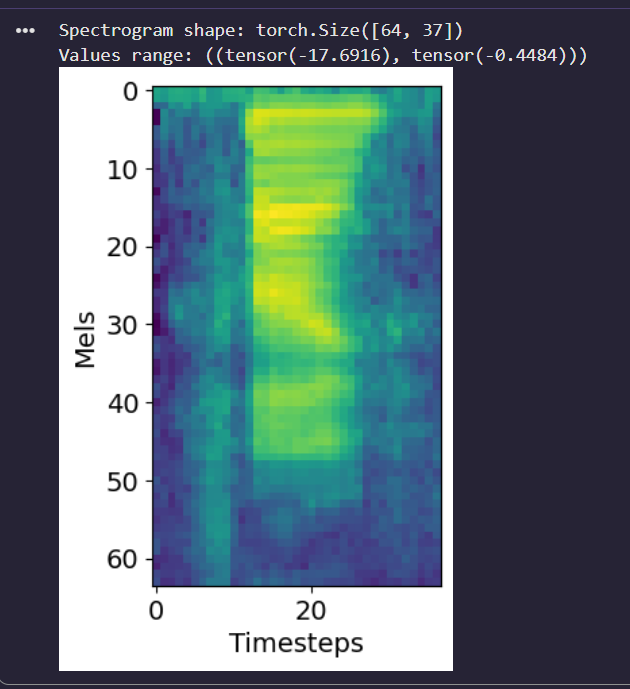

## Dataset Class

In [ ]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)

    def __len__(self):
      return len(self.items)

    def list_wavs_and_labels(self, root: str):
      base = Path(root)
      speakers = sorted([p for p in base.iterdir() if p.is_dir()])
      items = []
      for sp in speakers:
          for wav in sorted(sp.glob("**/*.wav")):
              # filename e.g., "9_10_0_0_1.wav" (digit_speaker_..)
              name = wav.stem.split("_")
              digit = int(name[0])
              speaker_id = sp.name
              items.append((str(wav), digit, speaker_id))
      return items

    '''def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav'''

    def load_wav(self, path):
        wav, sr = sf.read(path)
        wav = torch.from_numpy(wav).T.float()
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)

        if wav.dim() == 1:
            wav = wav.unsqueeze(0)
        wav = wav.mean(dim=0, keepdim=True)

        return wav


    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        return wav, label

def collate(batch):
    wavs, labels = zip(*batch)
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0).t() for w in wavs], batch_first=True)  # [B, Tw, 1]? we transposed; fix:
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels


# Ensure data loading correctly
_test_dataset = AudioMNISTDataset(root)
_test_dataset[0]

In [ ]:
def split_indices_by_speaker(dataset: AudioMNISTDataset, test_speakers: set):
    train_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs


# Split by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

In [ ]:
wav, label = next(iter(full_ds))

Audio(wav, rate=full_ds.sr)

## Augmentation Pipeline

In [ ]:
def pitchshift(audio, SAMPLE_RATE=16000, shift=2):
    if len(audio.shape) == 1:
        audio = audio.unsqueeze(0)
    elif len(audio.shape) == 2:
        audio = audio.unsqueeze(0)

    transform = transforms.PitchShift(sample_rate=SAMPLE_RATE, n_steps=shift)
    waveform_shift = transform(audio)

    return waveform_shift

def fade_in_out(audio):
    if len(audio.shape) == 1:
        audio = audio.unsqueeze(0).unsqueeze(0)
    elif len(audio.shape) == 2:
        audio = audio.unsqueeze(0)

    bs, ch, length = audio.shape

    _fade_shape = ['linear', 'logarithmic', 'exponential']
    augmented = []

    for i in range(bs):
        max_fade = length // 4
        fade_in_len = random.randint(1, max_fade)
        fade_out_len = random.randint(1, max_fade)
        fade_shape = random.choice(_fade_shape)

        transform = transforms.Fade(
            fade_in_len=fade_in_len,
            fade_out_len=fade_out_len,
            fade_shape=fade_shape
        )

        item_fade = transform(audio[i])
        augmented.append(item_fade)

    return torch.stack(augmented)

def add_white_noise_(signal, noise_level=0.1):
    noise = torch.randn_like(signal) * torch.std(signal) * noise_level
    noisy_signal = signal + noise
    return noisy_signal

def timemasking(waveform, sample_rate=16000):
    bs, ch, length = waveform.shape
    mask_len = random.randint(length // 16, length // 8)
    augmented = waveform.clone()

    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0

    return augmented

def random_augmentation(waveform, sample_rate=16000):
    if len(waveform.shape) == 1:
        waveform = waveform.unsqueeze(0).unsqueeze(0)  # [length] -> [1, 1, length]
    elif len(waveform.shape) == 2:
        waveform = waveform.unsqueeze(0)  # [channels, length] -> [1, channels, length]

    augmented = waveform.clone()

    augmentations = [
        (lambda x: timemasking(x, sample_rate), 1/4),
        (lambda x: add_white_noise_(x, noise_level=0.05), 1/4),
        (lambda x: pitchshift(x, sample_rate, shift=random.choice([-2, -1, 1, 2])), 1/4),
        (lambda x: fade_in_out(x), 1/4)
    ]

    for aug_func, prob in augmentations:
        if np.random.random() < prob:
            try:
                augmented = aug_func(augmented)
            except Exception as e:
                print(f"Error in augmentation {aug_func.__name__}: {e}")
                continue

    return augmented


def forced_augmentation(waveform, sample_rate=16000):
    if len(waveform.shape) == 1:
        waveform = waveform.unsqueeze(0).unsqueeze(0)
    elif len(waveform.shape) == 2:
        waveform = waveform.unsqueeze(0)

    augmented = waveform.clone()

    augmentations = [
        (lambda x: timemasking(x, sample_rate), 1/2),
        (lambda x: add_white_noise_(x, noise_level=0.07), 1),
        (lambda x: pitchshift(x, sample_rate, shift=random.choice([-2, -1, 1, 2])), 1/3),
        (lambda x: fade_in_out(x), 1/4)
    ]

    for aug_func, prob in augmentations:
        if np.random.random() < prob:
            try:
                augmented = aug_func(augmented)
            except Exception as e:
                print(f"Error in augmentation {aug_func.__name__}: {e}")
                continue

    return augmented

## ResNet 1d/2d Implementations

Для извлечения признаков из аудиосигналов были реализованы две вариации ResNet-архитектуры, каждая из которых имеет свою область применения:
1. ResNet1D прнимает на вход wav.
2. ResNet2D принимает на вход LogMelSpectrogram.

Каждая из моделей возрващает вектор размера 256.

### ResNet1d Implementation

In [ ]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(block, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm1d(out_channels)
        )

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        x = self.conv_layers(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)
        return x

class ResNet1D(nn.Module):
    def __init__(self, block, num_classes=2):
        super(ResNet1D, self).__init__()
        layers = [2, 2, 2, 2]
        self.expansion = 1
        self.in_channels = 64

        self.first_layers = nn.Sequential(
            nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(self.in_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # Блоки ResNet
        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)


    def forward(self, x):
        x = self.first_layers(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)

        return x

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels * self.expansion:
            identity_downsample = nn.Sequential(
                nn.Conv1d(self.in_channels, out_channels * self.expansion,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels * self.expansion)
            )

        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

def CreateResNet1D():
    return ResNet1D(block)

### ResNet2d Implementation

In [ ]:
class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(block_resnet2d, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        x = self.conv_layers(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)
        return x

class ResNet2D(nn.Module):
    def __init__(self, block, image_channels, num_classes=2):
        super(ResNet2D, self).__init__()
        layers = [2, 2, 2, 2]
        self.expansion = 1
        self.in_channels = 64

        self.first_layers = nn.Sequential(
            nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(self.in_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Блоки ResNet
        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.output_layers = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 * self.expansion, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.first_layers(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.output_layers(x)
        return x

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels * self.expansion:
            identity_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * self.expansion,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


def CreateResNet2D(img_channels=3, num_classes=2):
    return ResNet2D(block_resnet2d, image_channels=img_channels, num_classes=num_classes)

In [ ]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    if train_accuracies:
        ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    if test_accuracies:
        ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)

    if train_accuracies or test_accuracies:
        ax2.set_title('Accuracies')
        ax2.set_xlabel('Step')
        ax2.set_ylabel('Accuracy (%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

## 1. ResNet2D Classifier.



В данном разделе реализован ResNet2D Classifier + Cross Entropy Loss (обычный Supervised подход). Обучение производится на аугментированных данных в течение 10 эпох, с `batch_size=64`, каждую 5-ую итерацию (по батчам) производится валидация модели.

### Train/Validation Pipeline

In [ ]:
from IPython.display import clear_output

def train_resnet2d(model, optimizer, criterion, train_loader, valid_loader,
                   batch_size, n_epochs=8, scheduler=None):

    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)
    train_losses = []
    train_accuracies = []
    valid_losses = []
    valid_accuracies = []

    i = 0
    for epoch in range(n_epochs):

        epoch_train_losses, epoch_valid_losses = [], []
        epoch_train_accuracies, epoch_valid_accuracies = [], []

        for X, y in train_loader:

            model.train()
            optimizer.zero_grad()


            # Preproccess data and load it to device
            X = X.unsqueeze(1)
            X = random_augmentation(X, batch_size)

            X = X.to(device)
            X = mel_transform(X)

            X = X.to(device)
            y = y.to(device)

            # Forward pass
            predictions = model(X)
            train_loss = criterion(predictions, y)

            _, predicted = torch.max(predictions, 1)
            train_accuracy = (predicted == y).float().mean().item()

            epoch_train_losses.append(train_loss.item())
            epoch_train_accuracies.append(train_accuracy)

            train_loss.backward()
            optimizer.step()

            i += 1
            if i%5 == 0:
                # Evaluation
                model.eval()
                with torch.no_grad():
                    for X, y in valid_loader:
                        # load data to device
                        X = X.unsqueeze(1)

                        X = X.to(device)
                        X = mel_transform(X)

                        X, y = X.to(device), y.to(device)

                        # Forward pass
                        predictions = model(X)
                        valid_loss = criterion(predictions, y)

                        _, predicted = torch.max(predictions, 1)
                        valid_accuracy = (predicted == y).float().mean().item()

                        epoch_valid_losses.append(valid_loss.item())
                        epoch_valid_accuracies.append(valid_accuracy)

                epoch_train_loss = np.mean(epoch_train_losses)
                epoch_train_acc = np.mean(epoch_train_accuracies)
                epoch_valid_loss = np.mean(epoch_valid_losses)
                epoch_valid_acc = np.mean(epoch_valid_accuracies)

                train_losses.append(epoch_train_loss)
                train_accuracies.append(epoch_train_acc)
                valid_losses.append(epoch_valid_loss)
                valid_accuracies.append(epoch_valid_acc)

                #Сохранение модели.
                if i%20 == 0:
                    torch.save(model_supervised, 'complete_model_supervised.pth')

                if scheduler:
                    scheduler.step(epoch_valid_loss)

                plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
                clear_output(wait=True)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

In [ ]:
model_supervised = CreateResNet2D(img_channels=1, num_classes=10).to(device)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_supervised.parameters(), lr=1e-3)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.35,
    patience=10,
    min_lr=5e-6
)

In [ ]:
batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)

In [ ]:
model_supervised.train()
optimizer.zero_grad()

mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)

epoch_train_losses, epoch_valid_losses = [], []
epoch_train_accuracies, epoch_valid_accuracies = [], []


X, y = next(iter(train_loader))

# Preproccess data and load it to device
X = X.unsqueeze(1)
X = random_augmentation(X, batch_size)

X = X.to(device)

X = mel_transform(X)

X = X.to(device)
y = y.to(device)

# Forward pass
predictions = model_supervised(X)
train_loss = criterion(predictions, y)

_, predicted = torch.max(predictions, 1)
train_accuracy = (predicted == y).float().mean().item()
epoch_train_losses.append(train_loss.item())
epoch_train_accuracies.append(train_accuracy)
train_loss.backward()
optimizer.step()

In [ ]:
train_resnet2d(model_supervised, optimizer, criterion, train_loader, valid_loader, batch_size, 2, scheduler)

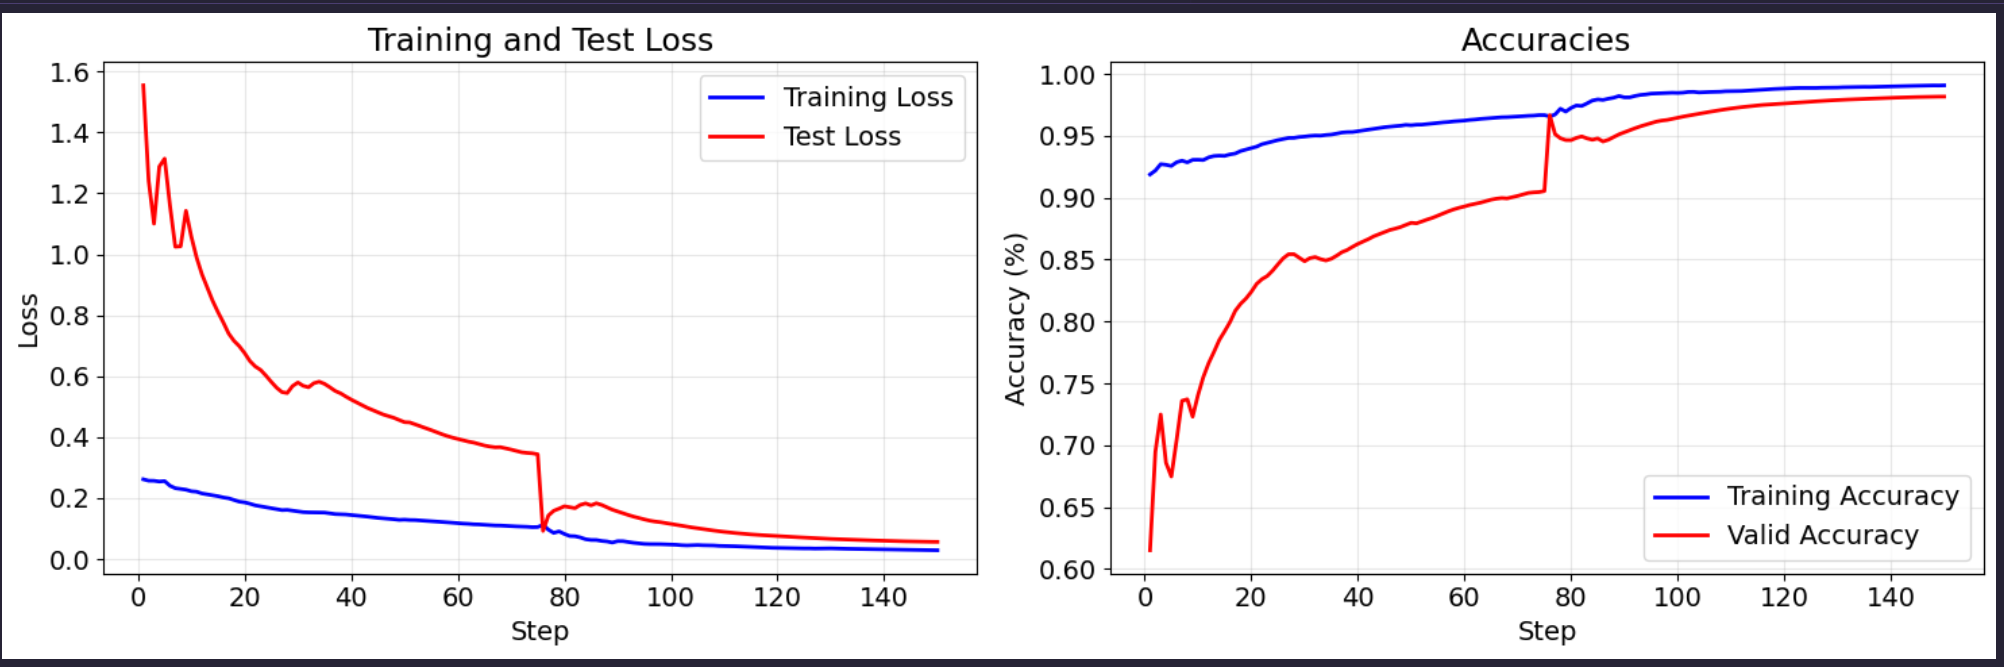

#### Сохранение модели:

In [ ]:
from google.colab import files

files.download('complete_model_supervised.pth')

## 2. Contrastive Loss.

In [ ]:
def create_input(X, mel_transform, device='cuda', augmentation=random_augmentation):
    audio = X.unsqueeze(1)
    if augmentation:
        audio = augmentation(audio, audio.shape[0])

    audio = audio.to(device)
    spectre = mel_transform(audio).to(device)

    return audio, spectre

In [ ]:
class ContrastiveNet(nn.Module):
    def __init__(self, img_channels, num_classes, device='cuda', resnet1d=None, resnet2d=None):
        super(ContrastiveNet, self).__init__()

        if not resnet1d:
            self.resnet1d = CreateResNet1D().to(device)
        else:
            self.resnet1d = resnet1d

        if not resnet2d:
            self.resnet2d = CreateResNet2D(img_channels=1, num_classes=10).to(device)
            self.resnet2d.output_layers = nn.Identity()
        else:
            self.resnet2d = resnet2d

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, audio, spectre):
        audio = self.resnet1d(audio).squeeze()
        spectre = self.resnet2d(spectre).squeeze()

        audio_embed = self.output(audio)
        spectre_embed = self.output(spectre)

        return audio_embed, spectre_embed, audio, spectre


class EvaluationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 10):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.evaluation(x)
        return x

In [ ]:
def device_as(t1, t2):
   return t1.to(t2.device)

class ContrastiveLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def calc_similarity_batch(self, a, b):
    rep = torch.cat([a,b])
    return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)

  def forward(self, proj_1, proj_2):
    batch_size = proj_1.shape[0]
    z_i = F.normalize(proj_1, p=2, dim=1)
    z_j = F.normalize(proj_2, p=2, dim=1)

    similarity_matrix = self.calc_similarity_batch(z_i, z_j)

    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji])

    nominator = torch.exp(positives / self.temperature)

    mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
    mask = device_as(mask, similarity_matrix)

    denominator = mask * torch.exp(similarity_matrix / self.temperature)
    all_losses = -torch.log(nominator / torch.sum(denominator))
    loss = torch.sum(all_losses) / (2*batch_size)

    return loss

In [ ]:
'''torch.serialization.add_safe_globals([ResNet2D])

resnet2d = torch.load('complete_model_supervised.pth', weights_only=False)

# Заменяем output_layers (классификационную голову) на Identity.
resnet2d.output_layers = nn.Identity()

resnet2d = resnet2d.to(device)'''

####Особенности обучения:
1. **ResNet1d + ResNet2d + Contrastive Loss**. При batch_size = 64, 1200 итераций (до визуальной сходимости), каждые 5 итераций производим валидацию и обучение **Eval Head**.
2. **Eval Head**. Фактически это логистическая регрессия, на вход ей подается вектор - сумма выходов ResNet1d и ResNet2d (параметры этих моделей замораживаются и через них не течет градиент).


####Оптимизаторы
1. **ResNet1d + ResNet2d**. Adam, lr = 1e-4;
2. **Eval Head (логистическая регрессия)**. Adam, lr = 1e-4;

#### Далее описан тренировочный цикл и представлены некоторые промежуточные результаты.

In [ ]:
def train_contrastive(model, eval_head, optimizer, criterion, train_loader, valid_loader,
                   batch_size=128, n_epochs=5, scheduler=None, stop=1000):

    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)

    eval_optimizer = torch.optim.Adam(eval_head.parameters(), lr=1e-4)
    eval_loss = nn.CrossEntropyLoss()

    train_losses, valid_losses, train_accuracies, valid_accuracies = [], [], [], []

    for param in model.parameters():
        param.requires_grad = True

    i = 0
    for epoch in range(n_epochs):
        epoch_train_losses, epoch_valid_losses = [], []

        for X, y in train_loader:
            model.train()
            eval_head.train()

            optimizer.zero_grad()

            #Очистка памяти.
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            audio, spectre = create_input(X, mel_transform)
            y = y.to(device)

            audio_embed, spectre_embed, audio_out, spectre_out = model(audio, spectre)
            train_loss = criterion(audio_embed, spectre_embed)

            epoch_train_losses.append(train_loss.item())

            train_loss.backward()
            optimizer.step()

            i += 1

            if i % 5 == 0:

                #Очистка памяти
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                train_accuracy, valid_accuracy = eval_head_train(model, eval_head, eval_loss, eval_optimizer,
                                               train_loader, mel_transform)
                train_accuracies.append(train_accuracy)
                valid_accuracies.append(valid_accuracy)

                valid_loss_value = validate_model(model, criterion, valid_loader, mel_transform)
                epoch_valid_losses.append(valid_loss_value)

                epoch_train_loss = np.mean(epoch_train_losses)
                epoch_valid_loss = np.mean(epoch_valid_losses)

                train_losses.append(epoch_train_loss)
                valid_losses.append(epoch_valid_loss)

                if scheduler:
                    scheduler.step(epoch_valid_loss)

                plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
                clear_output(wait=True)

            if i > stop:
                break


def eval_head_train(model, eval_head, eval_loss, eval_optimizer, train_loader,
                         mel_spectrogram, n_iters=10):

    original_requires_grad = {}
    for name, param in model.named_parameters():
        original_requires_grad[name] = param.requires_grad
        param.requires_grad = False

    train_accuracies, valid_accuracies = [], []

    eval_head.train()
    i = 0

    for X, y in train_loader:
        eval_optimizer.zero_grad()

        with torch.no_grad():
            audio, spectre = create_input(X, mel_spectrogram, device)
            _, _, audio_out, spectre_out = model(audio, spectre)

        y = y.to(device)

        combined = audio_out + spectre_out
        pred = eval_head(combined)
        loss = eval_loss(pred, y)

        loss.backward()
        eval_optimizer.step()

        with torch.no_grad():
            _, pred_max = torch.max(pred, 1)
            batch_accuracy = (pred_max == y).float().mean().item()
            train_accuracies.append(batch_accuracy)

        #Очистка памяти
        del audio, spectre, audio_out, spectre_out, combined, pred, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        i += 1
        if i > n_iters:
            break

    eval_head.eval()
    with torch.no_grad():
        for X, y in valid_loader:
            audio, spectre = create_input(X, mel_spectrogram, device)
            _, _, audio_out, spectre_out = model(audio, spectre)
            y = y.to(device)

            combined = audio_out + spectre_out
            pred = eval_head(combined)

            _, pred_max = torch.max(pred, 1)
            batch_accuracy = (pred_max == y).float().mean().item()
            valid_accuracies.append(batch_accuracy)

            #Очистка памяти
            del audio, spectre, audio_out, spectre_out, combined, pred
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    for name, param in model.named_parameters():
        param.requires_grad = original_requires_grad[name]

    return np.mean(train_accuracies), np.mean(valid_accuracies)

def validate_model(model, criterion, valid_loader, mel_transform):
    model.eval()
    valid_losses = []

    with torch.no_grad():
        for X, y in valid_loader:
            y = y.to(device)
            audio, spectre = create_input(X, mel_transform, device)

            audio_embed, spectre_embed, _, _ = model(audio, spectre)
            valid_loss = criterion(audio_embed, spectre_embed)
            valid_losses.append(valid_loss.item())

            #Очистка памяти
            del audio, spectre, audio_embed, spectre_embed, valid_loss
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    model.train()
    return np.mean(valid_losses)

In [ ]:
model_contrastive = ContrastiveNet(img_channels=1, num_classes=10).to(device)
eval_head = EvaluationHead().to(device)

In [ ]:
criterion = ContrastiveLoss()

#Предобученная модель resnet2d будет дообучаться медленнее resnet1d.
resnet2d_params, other_params = [], []

resnet2d_lr, other_lr = 1e-4, 1e-4

for name, param in model_contrastive.named_parameters():
    if 'resnet2d' in name:
        resnet2d_params.append(param)
    else:
        other_params.append(param)

groups = [
        {'params': resnet2d_params, 'lr': resnet2d_lr},
        {'params': other_params, 'lr': other_lr}
    ]

optimizer = torch.optim.Adam(groups)

In [ ]:
batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)

In [ ]:
train_contrastive(model_contrastive, eval_head, optimizer, criterion, train_loader, valid_loader,
                   batch_size, n_epochs=8, scheduler=None)

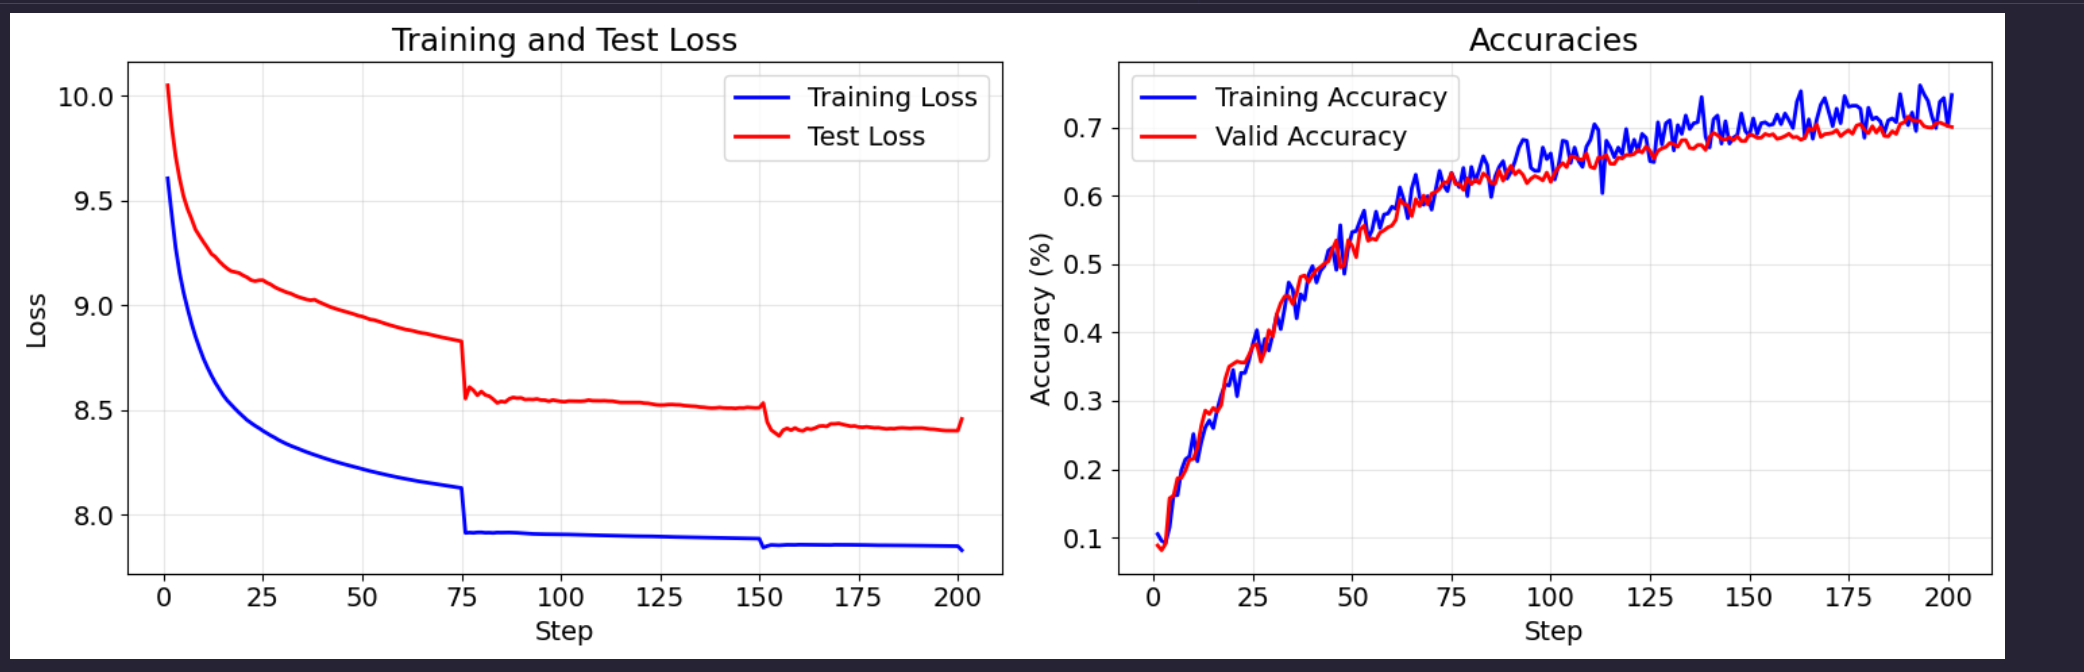

In [ ]:
train_contrastive(model_contrastive, eval_head, optimizer, criterion, train_loader, valid_loader,
                   batch_size, n_epochs=8, scheduler=None, stop=200)

Сохранение модели:

In [ ]:
torch.save(model_contrastive, 'complete_model_contrastive.pth')
torch.save(eval_head, 'eval_head_contrastive.pth')

from google.colab import files

files.download('complete_model_contrastive.pth')
files.download('eval_head_contrastive.pth')

##3. Barlow Twins Loss.
Более подробнее можно ознакомиться в статье:
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))


#### Barlow Twin Loss

In [ ]:
class BarlowTwinsLoss(nn.Module):
    def __init__(self, l=0.5):
        super(BarlowTwinsLoss, self).__init__()
        self.l = l

    def forward(self, a1, s1, a2, s2):
        x1 = a1 + s1
        x2 = a2 + s2

        batch_size, embed_size = x1.shape

        x1 = (x1 - x1.mean(dim=0)) / (x1.std(dim=0) + 1e-8)
        x2 = (x2 - x2.mean(dim=0)) / (x2.std(dim=0) + 1e-8)

        cross_corr = torch.mm(x1.T, x2) / batch_size

        on_diag = (1.0 - torch.diagonal(cross_corr)).pow(2).sum()

        total_squared = cross_corr.pow(2).sum()
        diag_squared = torch.diagonal(cross_corr).pow(2).sum()
        off_diag = total_squared - diag_squared

        loss_val = on_diag + self.l * off_diag

        return loss_val

####Особенности обучения:
1. **ResNet1d + ResNet2d + Barlow Twins Loss**. При batch_size = 64, 1200 итераций (до визуальной сходимости), каждые 5 итераций производим валидацию и обучение **Eval Head**.
2. **Eval Head**. Фактически это логистическая регрессия, на вход ей подается вектор - сумма выходов ResNet1d и ResNet2d (параметры этих моделей замораживаются и через них не течет градиент).


####Оптимизаторы
1. **ResNet1d + ResNet2d**. Adam, lr = 1e-4;
2. **Eval Head (логистическая регрессия)**. Adam, lr = 1e-4;

#### Далее описан тренировочный цикл и представлены некоторые промежуточные результаты.

In [ ]:


def train_barlow(model, eval_head, optimizer, criterion, train_loader, valid_loader,
                   batch_size=128, n_epochs=5, scheduler=None, stop=1000):

    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)

    eval_optimizer = torch.optim.Adam(eval_head.parameters(), lr=1e-4)
    eval_loss = nn.CrossEntropyLoss()

    train_losses, valid_losses, train_accuracies, valid_accuracies = [], [], [], []

    for param in model.parameters():
        param.requires_grad = True

    i = 0
    for epoch in range(n_epochs):
        epoch_train_losses, epoch_valid_losses = [], []

        for X, y in train_loader:
            model.train()
            eval_head.train()

            optimizer.zero_grad()

            #Очистка памяти.
            if torch.cuda.is_available():
                torch.cuda.empty_cache()


            audio, spectre = create_input(X, mel_transform)
            audio_aug, spectre_aug = create_input(X, mel_transform, device, forced_augmentation)
            y = y.to(device)

            audio_embed, spectre_embed, _, _  = model(audio, spectre)
            audio_embed_aug, spectre_embed_aug, _, _ = model(audio_aug, spectre_aug)

            train_loss = criterion(audio_embed, spectre_embed, audio_embed_aug, spectre_embed_aug)

            epoch_train_losses.append(train_loss.item())

            train_loss.backward()
            optimizer.step()

            i += 1

            if i % 5 == 0:

                #Очистка памяти
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                train_accuracy, valid_accuracy = eval_head_train(model, eval_head, eval_loss, eval_optimizer,
                                               train_loader, mel_transform)
                train_accuracies.append(train_accuracy)
                valid_accuracies.append(valid_accuracy)

                valid_loss_value = validate_model(model, criterion, valid_loader, mel_transform)
                epoch_valid_losses.append(valid_loss_value)

                epoch_train_loss = np.mean(epoch_train_losses)
                epoch_valid_loss = np.mean(epoch_valid_losses)

                train_losses.append(epoch_train_loss)
                valid_losses.append(epoch_valid_loss)

                if scheduler:
                    scheduler.step(epoch_valid_loss)

                plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
                clear_output(wait=True)

            if i > stop:
                break


def eval_head_train(model, eval_head, eval_loss, eval_optimizer, train_loader,
                         mel_spectrogram, n_iters=10):

    original_requires_grad = {}
    for name, param in model.named_parameters():
        original_requires_grad[name] = param.requires_grad
        param.requires_grad = False

    train_accuracies, valid_accuracies = [], []

    eval_head.train()
    i = 0

    for X, y in train_loader:
        eval_optimizer.zero_grad()

        with torch.no_grad():
            audio, spectre = create_input(X, mel_spectrogram, device)
            _, _, audio_out, spectre_out = model(audio, spectre)

        y = y.to(device)

        combined = audio_out + spectre_out
        pred = eval_head(combined)
        loss = eval_loss(pred, y)

        loss.backward()
        eval_optimizer.step()

        with torch.no_grad():
            _, pred_max = torch.max(pred, 1)
            batch_accuracy = (pred_max == y).float().mean().item()
            train_accuracies.append(batch_accuracy)

        #Очистка памяти
        del audio, spectre, audio_out, spectre_out, combined, pred, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        i += 1
        if i > n_iters:
            break

    eval_head.eval()
    with torch.no_grad():
        for X, y in valid_loader:
            audio, spectre = create_input(X, mel_spectrogram, device)
            _, _, audio_out, spectre_out = model(audio, spectre)
            y = y.to(device)

            combined = audio_out + spectre_out
            pred = eval_head(combined)

            _, pred_max = torch.max(pred, 1)
            batch_accuracy = (pred_max == y).float().mean().item()
            valid_accuracies.append(batch_accuracy)

            #Очистка памяти
            del audio, spectre, audio_out, spectre_out, combined, pred
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    for name, param in model.named_parameters():
        param.requires_grad = original_requires_grad[name]

    return np.mean(train_accuracies), np.mean(valid_accuracies)

def validate_model(model, criterion, valid_loader, mel_transform):
    model.eval()
    valid_losses = []

    with torch.no_grad():
        for X, y in valid_loader:
            y = y.to(device)

            audio, spectre = create_input(X, mel_transform, device)
            audio_aug, spectre_aug = create_input(X, mel_transform, device, forced_augmentation)

            audio_embed, spectre_embed, _, _ = model(audio, spectre)
            audio_embed_aug, spectre_embed_aug, _, _ = model(audio_aug, spectre_aug)
            valid_loss = criterion(audio_embed, spectre_embed, audio_embed_aug, spectre_embed_aug)
            valid_losses.append(valid_loss.item())

            #Очистка памяти
            del audio, spectre, audio_embed, spectre_embed, valid_loss
            del audio_aug, spectre_aug, audio_embed_aug, spectre_embed_aug
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    model.train()
    return np.mean(valid_losses)


In [ ]:
#Берем ту же модель, но производим обучение с новой функцией потерь.
model_barlow = ContrastiveNet(img_channels=1, num_classes=10).to(device)
eval_head = EvaluationHead().to(device)

In [ ]:
criterion = BarlowTwinsLoss()

#Предобученная модель resnet2d будет дообучаться медленнее resnet1d.
resnet2d_params, other_params = [], []

resnet2d_lr, other_lr = 1e-4, 1e-4

for name, param in model_barlow.named_parameters():
    if 'resnet2d' in name:
        resnet2d_params.append(param)
    else:
        other_params.append(param)

groups = [
        {'params': resnet2d_params, 'lr': resnet2d_lr},
        {'params': other_params, 'lr': other_lr}
    ]

optimizer = torch.optim.Adam(groups)

In [ ]:
batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)

In [ ]:
if torch.cuda.is_available():
                torch.cuda.empty_cache()

train_barlow(model_barlow, eval_head, optimizer, criterion, train_loader, valid_loader,
                   batch_size, n_epochs=8, scheduler=None, stop=1200)

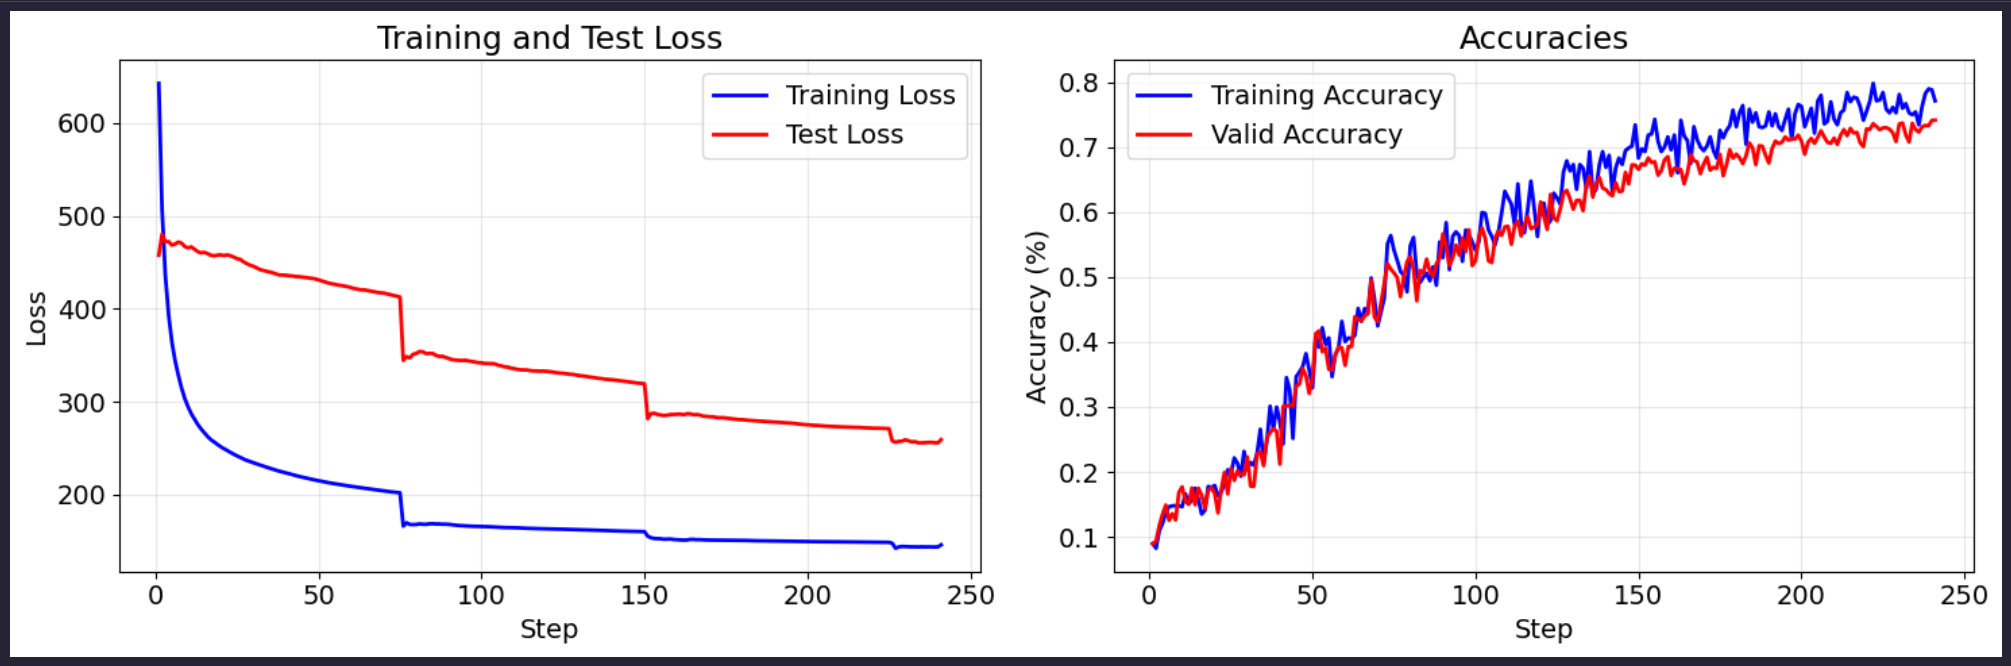

Сохраняем модели:

In [ ]:
torch.save(model_barlow, 'complete_model_barlow.pth')
torch.save(eval_head, 'eval_head_barlow.pth')

from google.colab import files

files.download('complete_model_barlow.pth')
files.download('eval_head_barlow.pth')

## Comparison.

В данном разделе приведены результаты сравнения двух описанных выше моделей для задачи классификации (в последнем разделе будет произведен fine tunning моделей, пока в качестве классификатора по входному эмбеддингу используются классификационные головы); для моделей, обученных с помощью SSL подхода (на 1200 батчах, batch_size = 64), проанализировано качество разделимости классов, визуализированное с помощью t-SNE.

In [ ]:
torch.serialization.add_safe_globals([ResNet2D, ContrastiveNet])

model_contrastive = torch.load('/content/complete_model_contrastive.pth', weights_only=False)
eval_head_contrastive = torch.load('/content/eval_head_contrastive.pth', weights_only=False)

model_barlow = torch.load('complete_model_barlow.pth', weights_only=False)
eval_head_barlow = torch.load('eval_head_barlow.pth', weights_only=False)

In [ ]:
batch_size = 64
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)

#### Mean Accuracy score

In [ ]:

contrastive_acc = []
barlow_acc = []


model_contrastive.eval()
model_barlow.eval()
eval_head_contrastive.eval()
eval_head_barlow.eval()

with torch.no_grad():
    for X, y in valid_loader:

        #Contrastive
        audio, spectre = create_input(X, mel_transform, device, None)
        y = y.to(device)

        audio_embed, spectre_embed, audio, spectre = model_contrastive(audio, spectre)

        pred = eval_head_contrastive(audio + spectre)
        _, pred = torch.max(pred, 1)

        acc = (y == pred).float().mean()

        contrastive_acc.append(acc.cpu().detach().numpy())


        #Barlow
        audio, spectre = create_input(X, mel_transform, device, None)
        y = y.to(device)

        audio_embed, spectre_embed, audio, spectre = model_barlow(audio, spectre)

        pred = eval_head_barlow(audio + spectre)
        _, pred = torch.max(pred, 1)

        acc = (y == pred).float().mean()

        barlow_acc.append(acc.cpu().detach().numpy())

print(f'Contrastive Learning: {np.mean(contrastive_acc)}')
print(f'Barlow Twins: {np.mean(barlow_acc)}')

#### Mean Accuracy Score:

#### 1. Contrastive Loss: 0.7376440167427063
#### 2. Barlow Twins Loss:  0.744071364402771

#### Clasters

In [ ]:
def extract_embeddings(model, dataloader):
    model.eval()
    progress_bar = tqdm(total=len(dataloader), unit='step')
    embeddings_audio = []
    embeddings_spec = []
    labels_ = []
    with torch.no_grad():
        for i, (audio,labels) in enumerate(dataloader):

            audio = audio.to(device)
            audios, spectrograms = create_input(audio, mel_transform,
                                               device,  augmentation=None)

            # Use frozen encoder
            _, _, frozen_audio, frozen_spects = model(audios, spectrograms)
            #embed = torch.cat([frozen_audio, frozen_spects], dim = 0).cpu()
            embeddings_audio.append(frozen_audio.cpu())
            embeddings_spec.append(frozen_spects.cpu())
            labels_.append(labels.cpu())

            progress_bar.update(1)

        # end for batch
    return torch.cat(embeddings_audio, dim=0).numpy(), torch.cat(embeddings_spec, dim=0).numpy(), torch.cat(labels_, dim=0).numpy()


def tsne_plot(X: np.ndarray, y: np.ndarray, out_path: str = "tsne.png", name = ""):
    # Compute 2D t-SNE and save
    tsne = TSNE(n_components=2, init="random", learning_rate="auto", perplexity=min(30, max(5, len(X)//50)), n_iter=1000)
    X2 = tsne.fit_transform(X)
    plt.figure(figsize=(7, 6))
    for cls in sorted(set(y.tolist())):
        idx = (y == cls)
        plt.scatter(X2[idx, 0], X2[idx, 1], label=str(cls), s=10, alpha=0.7)
    plt.legend(title="Digit", loc="best")
    plt.title(f"t-SNE of {name} embeddings (AudioMNIST)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"Saved t-SNE figure to {out_path}")

In [ ]:
_embeddings_audio, _embeddings_spec, _labels = extract_embeddings(model_contrastive, train_loader)
tsne_plot(_embeddings_audio, _labels, name="audio")
tsne_plot(_embeddings_spec, _labels, name="spectrogram")

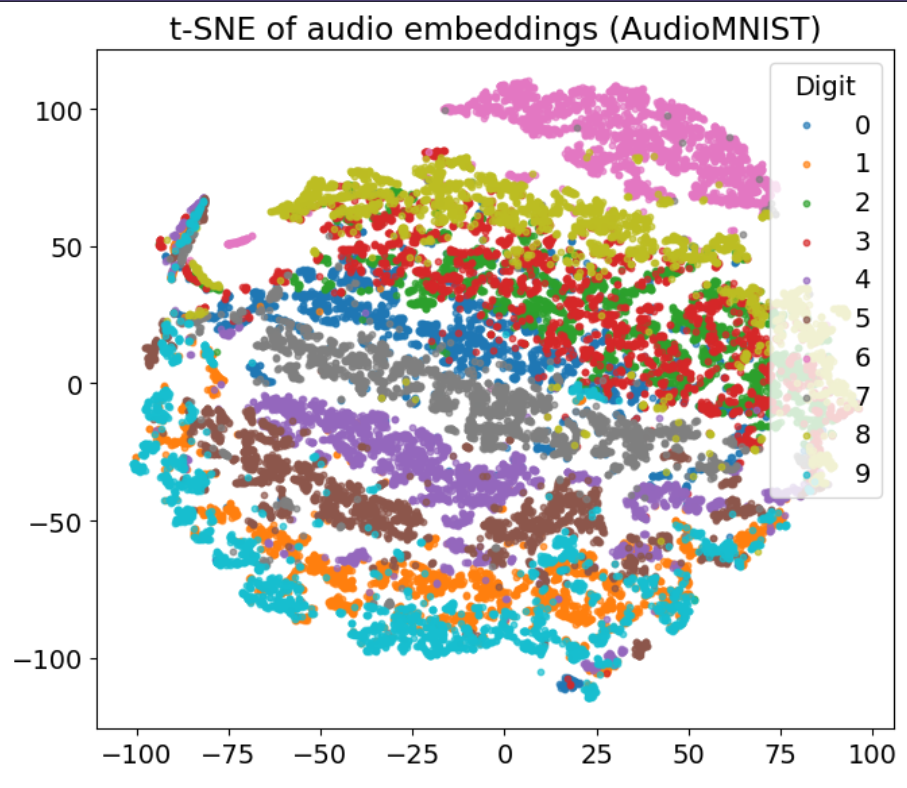



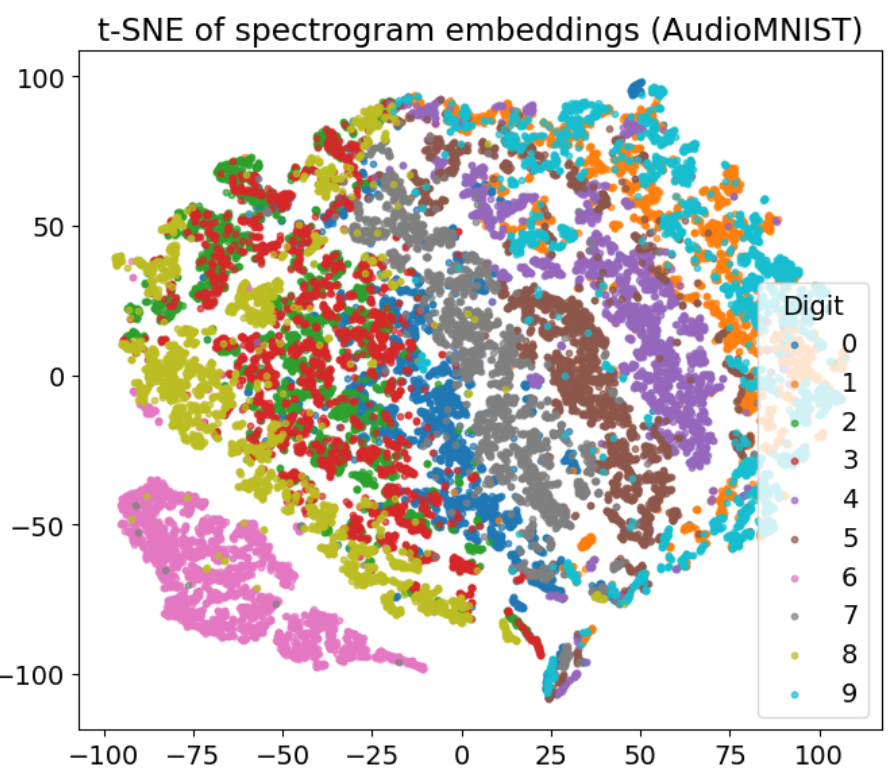

In [ ]:
_embeddings_audio, _embeddings_spec, _labels = extract_embeddings(model_barlow, train_loader)
tsne_plot(_embeddings_audio, _labels, name="audio")
tsne_plot(_embeddings_spec, _labels, name="spectrogram")

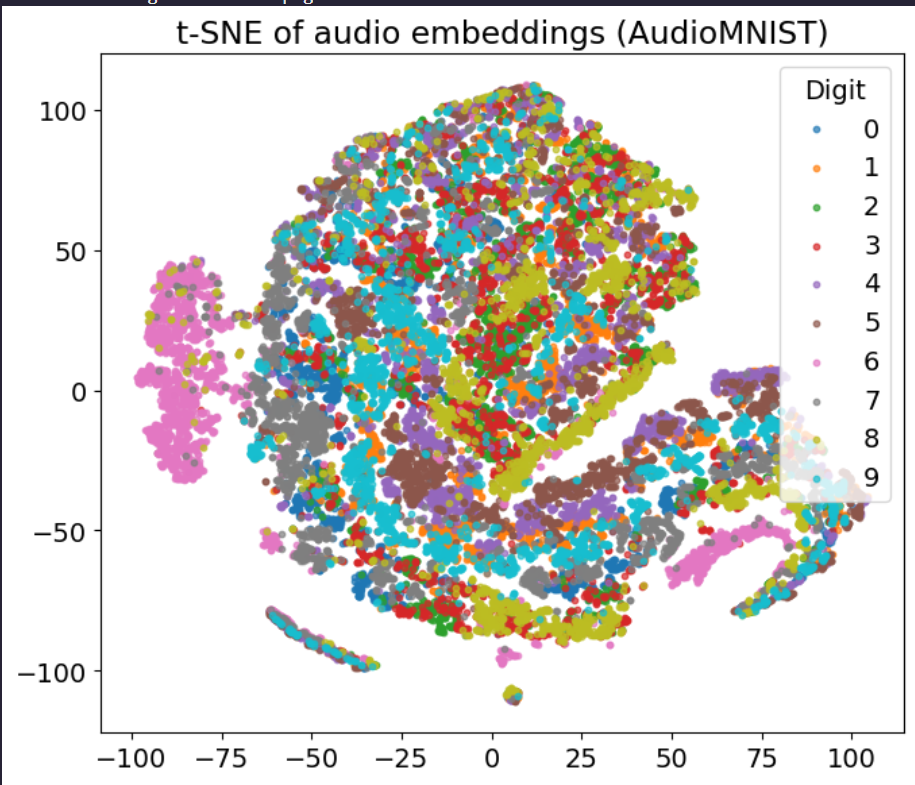

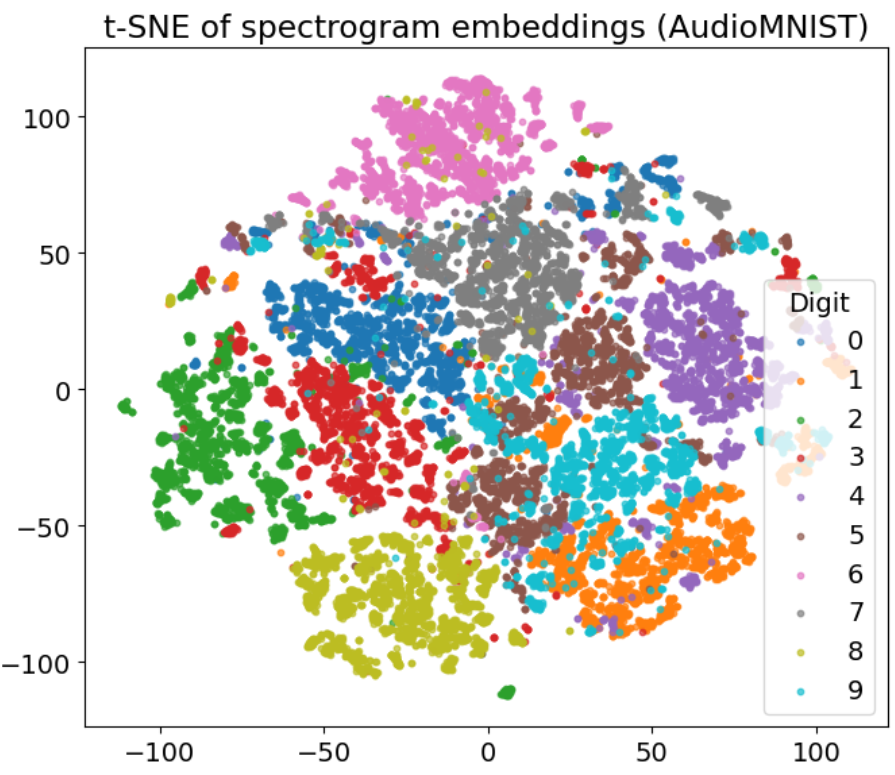

###Вывод:


1. **Contrastive Loss**: стабильная, но неидеальная кластеризация. Обе модальности (1D и 2D) показывают в некотором смысле согласованную картину (это, в некотором смысле, понятно из того, как устроен Contrastive Loss).


    * Цифра 6 образует четкий изолированный кластер в обоих представлениях,

    * Остальные цифры (за исключением цифр 2, 3) являются слоями некоторого большого облака (несколько субкластеров).

    * Цифры 2, 3 занимают некоторый смежный слой в облаке.

2. **Barlow Twins Loss**: наблюдается контраст между модальностями.
    * ResNet1D (аудио): Плохая структуризация — некоторые цифры образуют спиралевидные "слои" в общем облаке, некоторые "размазаны" по всему обалку, можно выделить только цифру 6, которая образует два кластера;

    * ResNet2D (спектрограммы): Наилучшая структура среди всех графиков, большинство цифр образуют образуют один - два слоя в некотором общем облаке (на самом деле то, что облако общее - небольшой недостаток).

##Fine Tuning.

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, num_classes = 10):
        super(MLPClassifier, self).__init__()

        self.mlp = nn.Sequential(
            nn.Linear(512, 128),
            nn.Sigmoid(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.mlp(x)
        return x

In [ ]:
#Contrastive Loss.
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)

classifier = MLPClassifier().to(device)

model = torch.load('/content/complete_model_contrastive.pth', weights_only=False).to(device)
model.eval()

optimizer = optim.Adam(params=classifier.parameters(), lr=2e-4)
loss_func = nn.CrossEntropyLoss()

mel_spectrogram = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)

train_accuracies, train_losses = [], []
for i in range(10):
    for X, y in train_loader:
        optimizer.zero_grad()

        with torch.no_grad():
            audio, spectre = create_input(X, mel_spectrogram, device)
            _, _, audio_out, spectre_out = model(audio, spectre)

        y = y.to(device)

        combined = audio_out + spectre_out
        pred = classifier(combined)
        loss = loss_func(pred, y)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            _, pred_max = torch.max(pred, 1)
            batch_accuracy = (pred_max == y).float().mean().item()
            train_accuracies.append(batch_accuracy)

        print(i, train_accuracies[-1])
        clear_output(wait=True)


In [ ]:
#Val set.
contrastive_acc = []

batch_size = 128
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)

model.eval()
classifier.eval()

with torch.no_grad():
    for X, y in valid_loader:

        #Contrastive
        audio, spectre = create_input(X, mel_transform, device, None)
        y = y.to(device)

        audio_embed, spectre_embed, audio, spectre = model(audio, spectre)

        pred = classifier(audio + spectre)
        _, pred = torch.max(pred, 1)

        acc = (y == pred).float().mean()

        contrastive_acc.append(acc.cpu().detach().numpy())


print(f'Contrastive Learning: {np.mean(contrastive_acc)}')

In [ ]:
#Barlow Twins Loss. Берем обе модальности, хотя можно брать только выход ResNet2d.
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)

barlow_classifier = MLPClassifier().to(device)

barlow_model = torch.load('/content/complete_model_barlow.pth', weights_only=False).to(device)
barlow_model.eval()

optimizer = optim.Adam(params=barlow_classifier.parameters(), lr=2e-4)
loss_func = nn.CrossEntropyLoss()

mel_spectrogram = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)

train_accuracies, train_losses = [], []
for i in range(10):
    for X, y in train_loader:
        optimizer.zero_grad()

        with torch.no_grad():
            audio, spectre = create_input(X, mel_spectrogram, device)
            _, _, audio_out, spectre_out = barlow_model(audio, spectre)

        y = y.to(device)

        combined = audio_out + spectre_out
        pred = barlow_classifier(combined)
        loss = loss_func(pred, y)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            _, pred_max = torch.max(pred, 1)
            batch_accuracy = (pred_max == y).float().mean().item()
            train_accuracies.append(batch_accuracy)

        print(i, train_accuracies[-1])
        clear_output(wait=True)

In [ ]:
#Val set.
barlow_acc = []

batch_size = 128
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128,
                                  n_mels=128, f_min=40, f_max=8000).to(device)

barlow_model.eval()
barlow_classifier.eval()

with torch.no_grad():
    for X, y in valid_loader:

        #Contrastive
        audio, spectre = create_input(X, mel_transform, device, None)
        y = y.to(device)

        audio_embed, spectre_embed, audio, spectre = barlow_model(audio, spectre)

        pred = barlow_classifier(audio + spectre)
        _, pred = torch.max(pred, 1)

        acc = (y == pred).float().mean()

        barlow_acc.append(acc.cpu().detach().numpy())


print(f'Barlow Twins: {np.mean(barlow_acc)}')

#### Mean Accuracy Score (после 10 эпох Fine Tuning'а):
####1. Barlow Twins: 0.8026453256607056,
####2. Contrastive Learning: 0.7398841381072998.



####Модели показали приемлемый результат. Стоит отметить, что модель, обученная с Barlow Twins Loss, может быть адаптирована под задачу классификации. Если увеличить число эпох при тюнинге модель показывает точность близкую к 0.9, это является хорошим результатом при ограниченных вычислительных ресурсах.  